In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
population_size = 100000
population_mu = 37.5
population_sigma = 4

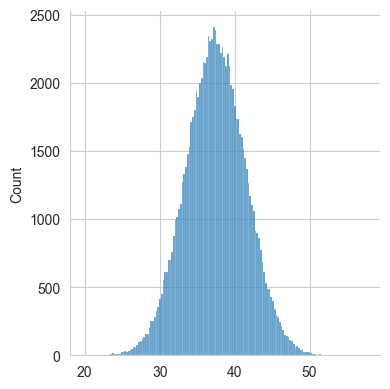

In [3]:
rng = np.random.default_rng(seed=42)
population = rng.normal(size=population_size, loc=population_mu, scale=population_sigma)
sns.displot(population, height=4);

In [4]:
def get_score_sample(population, population_mu, sample_size):
    #Считаем статистики выборки
    sample = np.random.choice(population, size=sample_size, replace=True)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample)

    # Проверяем, чтобы sample_std не был равен 0
    if sample_std == 0:
        return np.nan  # Возвращаем NaN, чтобы исключить из расчета

    z_score = (sample_mean - population_mu) / (sample_std / np.sqrt(len(sample)))
    t_score = (sample_mean - population_mu) / (sample_std / np.sqrt(len(sample) - 1))

    return z_score, t_score

In [8]:
def show_charts(z_scores, t_scores, x_limit=True):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, sharex=True)
    
    sns.histplot(z_scores, ax=axes[0])
    axes[0].set_title('z_scores')
    
    sns.histplot(t_scores, ax=axes[1])
    axes[1].set_title('t_scores')
    
    if x_limit:
        plt.xlim(-10, 10)
    
    plt.tight_layout()
    plt.show()

In [10]:
z_scores, t_scores = [], []
for i in range(1000):
    z, t = get_score_sample(population=population, population_mu=population_mu, sample_size=2)
    z_scores.append(z)
    t_scores.append(t)

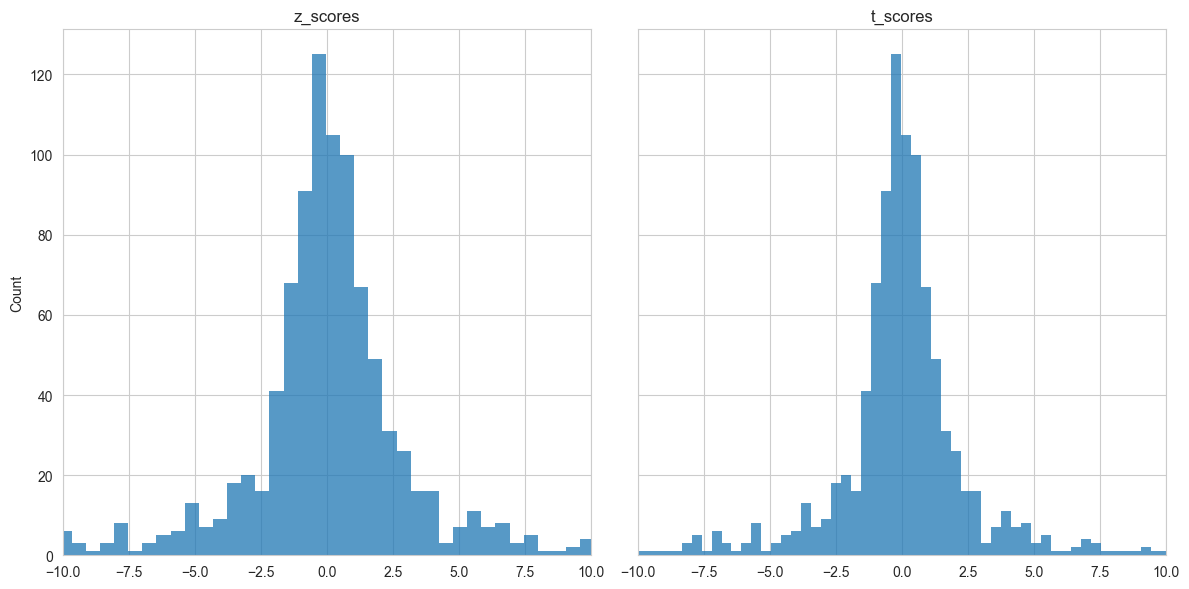

In [11]:
show_charts(z_scores, t_scores)

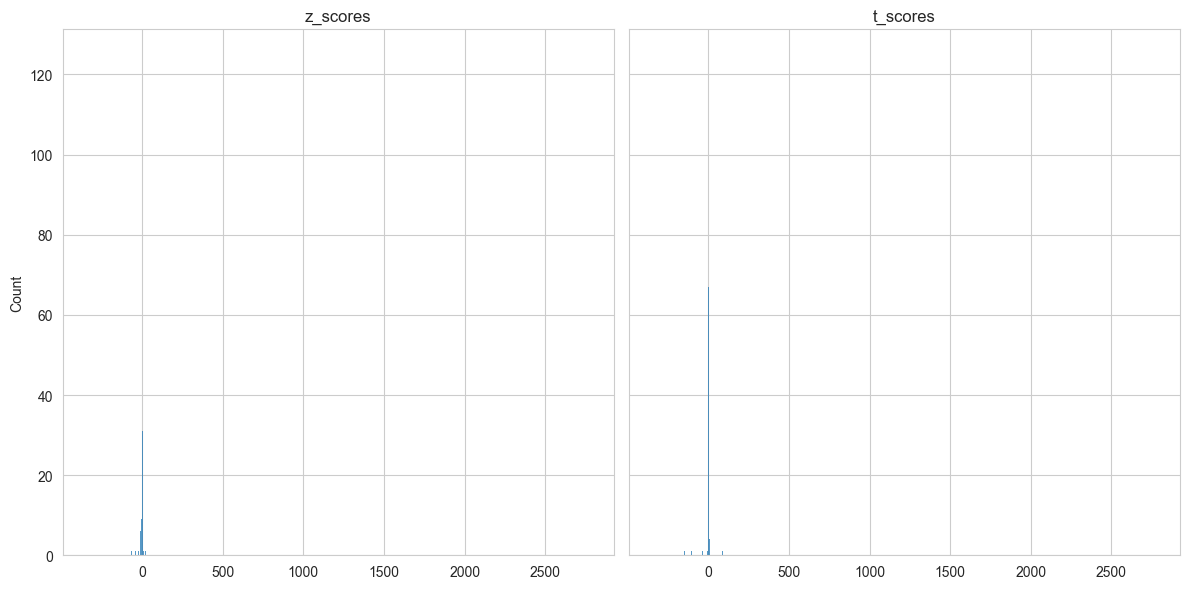

In [12]:
show_charts(z_scores, t_scores, x_limit=False)

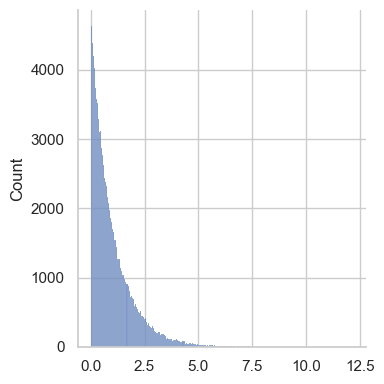

In [15]:
# Попробуем Т-теста на Экспоненциальном распределении
rng = np.random.default_rng(seed=42)
population_exp = rng.exponential(scale=1, size=100_000)
sns.displot(population_exp, height=4);

In [19]:
z_scores, t_scores = [], []
for i in range(10000):
    z, t = get_score_sample(population=population_exp, population_mu=np.mean(population_exp), sample_size=2)
    z_scores.append(z)
    t_scores.append(t)

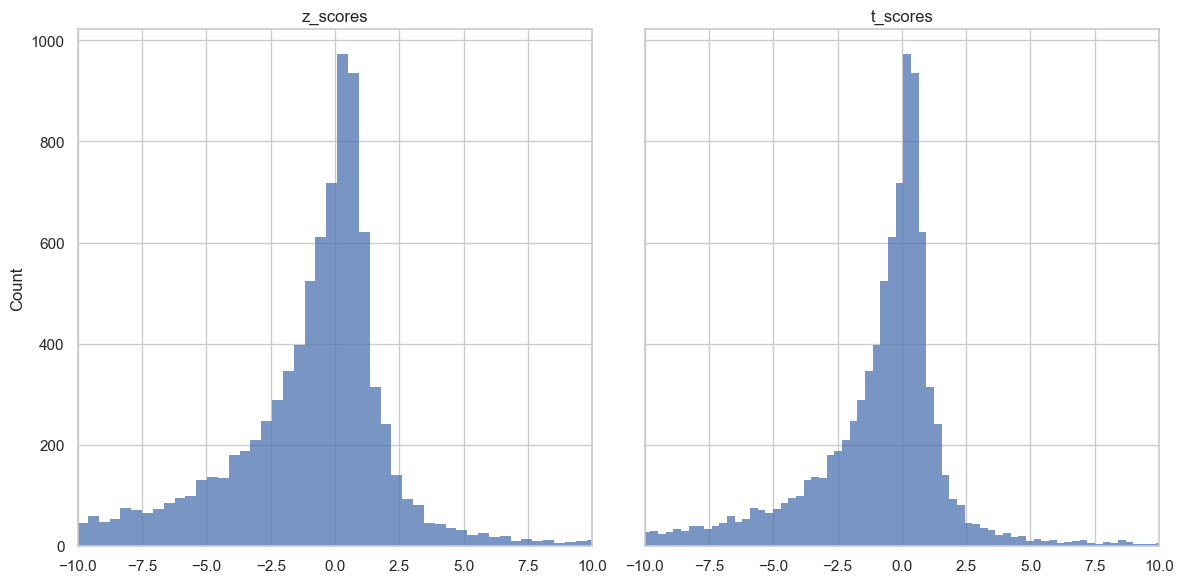

In [20]:
show_charts(z_scores, t_scores)